In [1]:

import os
import sys
import importlib
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import librosa
from tslearn.preprocessing import TimeSeriesScalerMeanVariance
from tslearn.utils import to_time_series_dataset
from tslearn.shapelets import LearningShapelets

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, f1_score, confusion_matrix, 
    classification_report, ConfusionMatrixDisplay, balanced_accuracy_score
)

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset

import utils
import shapelet_utils
from SoftShape_repo.models.SoftShapeModel import SoftShapeNet


from utils import (
    extract_features_from_audio, 
    evaluate_shapelet_classifier,
    split_dataset_into_chunks,  
    evaluate_song_level
)
from shapelet_utils import (
    optimize_shapelets, 
    extract_softshape_filters, 
    analyze_shapelet_importance
)
from pyts.transformation import ShapeletTransform
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from sklearn.model_selection import GridSearchCV

from sktime.transformations.panel.shapelet_transform import RandomShapeletTransform

warnings.filterwarnings('ignore')
MP3_DIR = "/Users/lorenzoallegrini/Downloads/fedez_fibra"
ARTIST_MAP = {"07024718": "Fedez", "25707984": "Fabri Fibra"}

def get_artist(f): 
    return ARTIST_MAP.get(f.split(' - ')[0].replace('ART', ''), "Unknown")

if not os.path.exists(MP3_DIR): raise FileNotFoundError(f"Path not found: {MP3_DIR}")

# Raggruppa file per artista in una sola passata
files = {k: [] for k in ARTIST_MAP.values()}
for f in os.listdir(MP3_DIR):
    if f.endswith('.mp3') and (art := get_artist(f)) in files:
        files[art].append(os.path.join(MP3_DIR, f))

print(f"Found: {len(files['Fedez'])} Fedez, {len(files['Fabri Fibra'])} Fibra")
all_files = files['Fedez'] + files['Fabri Fibra']
fedez_files = files['Fedez']
fibra_files = files['Fabri Fibra']

Loading CLAP Model...
Found: 179 Fedez, 275 Fibra


## Shapelet Extraction (Task 4.2)
We use **LearningShapelets** to find shapelets (discriminative subsequences) that best separate Fedez from Fabri Fibra.

In [2]:
import librosa
TARGET_SR = 10
sr = 24000

target_length_seconds = np.percentile([librosa.get_duration(path=f) for f in all_files], 5)
target_length_samples = int(target_length_seconds * sr)

labels = []
centered_songs = []
for file in all_files:
    y, _ = librosa.load(file, sr=sr)
    if len(y) < target_length_samples:
        continue
    start = len(y) // 2 - target_length_samples // 2
    centered_songs.append(y[start:start + target_length_samples])
    labels.append(1 if file in fedez_files else 0)

print(f"Extracted {len(centered_songs)} segments of {target_length_seconds:.1f}s")

np.array(centered_songs).shape

Extracted 431 segments of 123.9s


(431, 2973891)

In [3]:
feature_data, _ = extract_features_from_audio(
    centered_songs, 
    sr=sr,
    feature_list=['rms', 'spectral_centroid', 'spectral_bandwidth', 'spectral_rolloff', 'zero_crossing_rate'],
    target_sr=10,
    sigma=3.0
)
scaler = TimeSeriesScalerMeanVariance()

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
X_scaled = TimeSeriesScalerMeanVariance().fit_transform(to_time_series_dataset(np.array(feature_data)))
X_train, X_test, y_train, y_test = train_test_split(X_scaled, labels, test_size=0.2, random_state=42, stratify=labels)
X_train.shape

(344, 1239, 5)

## Shapelet Transform

In [ ]:
def run_shapelet_pipeline(X_train_data, y_train_data, X_test_data, y_test_data, 
                          feature_names, base_pipeline, param_grid):
    """
    Runs a configurable shapelet pipeline for each feature channel.
    The base_pipeline should contain 'st' for the transformer and 'clf' for the classifier.
    """
    results_store = []
    
    # Sktime safety: ensure y is a numpy array
    y_train_safe = np.array(y_train_data)
    
    for i, f_name in enumerate(feature_names):
        print(f"Processing feature: {f_name}...")
        
        # 1. Reshaping for sktime (Samples, Channels, Time)
        X_train_uni = X_train_data[:, :, i].astype(np.float32)[:, np.newaxis, :]
        X_test_uni = X_test_data[:, :, i].astype(np.float32)[:, np.newaxis, :]

        # 2. Optimization using the passed base_pipeline
        # We use cv=2 due to small sample size (22)
        grid = GridSearchCV(base_pipeline, param_grid, cv=3, scoring='balanced_accuracy', n_jobs=-1)
        
        try:
            grid.fit(X_train_uni, y_train_safe)
            best_model = grid.best_estimator_
            preds = best_model.predict(X_test_uni)
            probs = best_model.predict_proba(X_test_uni)

            results_store.append({
                'feature': f_name,
                'model': best_model,
                'best_params': grid.best_params_,
                'cv_score': grid.best_score_,
                'test_score': accuracy_score(y_test_data, preds),
                'preds': preds,
                'probs': probs[:, 1]
            })
        except Exception as e:
            print(f"Error processing {f_name}: {e}")

    return results_store

def plot_sktime_results(results_store, class_names=['Fibra', 'Fedez']):
    """
    Visualizes metrics and extracted shapelets from the results_store list.
    """
    for res in results_store:
        print(f"\n{'='*40}\n SKTIME ANALYSIS: {res['feature']} \n{'='*40}")
        
        # Metrics Visualization
        evaluate_shapelet_classifier(
            y_test, 
            res['preds'], 
            y_prob=res['probs'], 
            class_names=class_names
        )
        
        # Shapelet Extraction (Handling sktime tuple format)
        transformer = res['model'].named_steps['st']
        shapelet_data = transformer.shapelets
        
        if len(shapelet_data) > 0:
            plt.figure(figsize=(15, 4))
            plt.suptitle(f"Top Random Shapelets - {res['feature']}", fontsize=14)
            
            # Sktime tuple: (gain, length, start, column, data)
            for idx, s_tuple in enumerate(shapelet_data[:3]): 
                s_values = s_tuple[-1] 
                plt.subplot(1, 3, idx + 1)
                plt.plot(s_values, color='tab:red', linewidth=2)
                plt.title(f"Shapelet {idx+1} (Len: {len(s_values)})")
                plt.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.show()
        
feature_names=['RMS', 'Spectral Centroid', 'Bandwidth', 'Rolloff', 'ZCR']

### Random Forest

Processing feature: RMS...
Processing feature: Spectral Centroid...
Processing feature: Bandwidth...
Processing feature: Rolloff...
Processing feature: ZCR...

 SKTIME ANALYSIS: RMS 
CLASSIFICATION METRICS
ACCURACY    : 0.7471
PRECISION   : 0.7308
RECALL      : 0.5588
F1          : 0.6333
BALANCED_ACCURACY: 0.7134
ROC_AUC     : 0.7525

              precision    recall  f1-score   support

       Fibra       0.75      0.87      0.81        53
       Fedez       0.73      0.56      0.63        34

    accuracy                           0.75        87
   macro avg       0.74      0.71      0.72        87
weighted avg       0.74      0.75      0.74        87



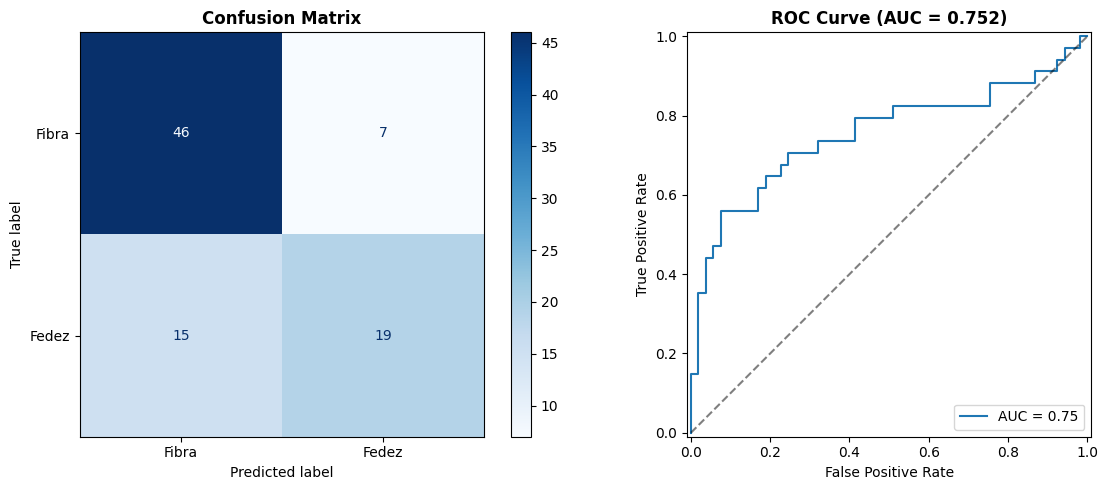

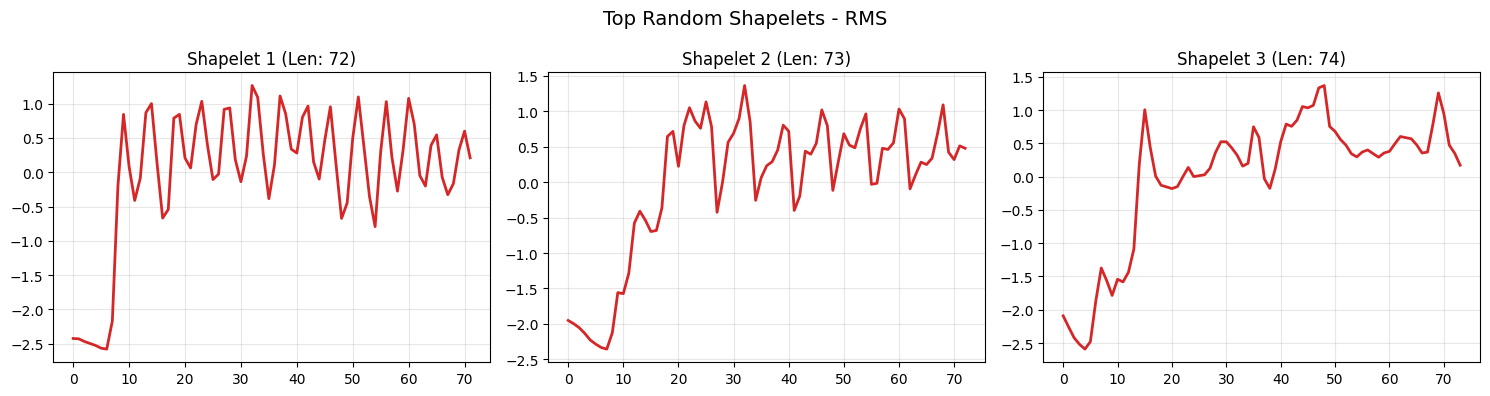


 SKTIME ANALYSIS: Spectral Centroid 
CLASSIFICATION METRICS
ACCURACY    : 0.5632
PRECISION   : 0.4000
RECALL      : 0.2353
F1          : 0.2963
BALANCED_ACCURACY: 0.5044
ROC_AUC     : 0.6365

              precision    recall  f1-score   support

       Fibra       0.61      0.77      0.68        53
       Fedez       0.40      0.24      0.30        34

    accuracy                           0.56        87
   macro avg       0.51      0.50      0.49        87
weighted avg       0.53      0.56      0.53        87



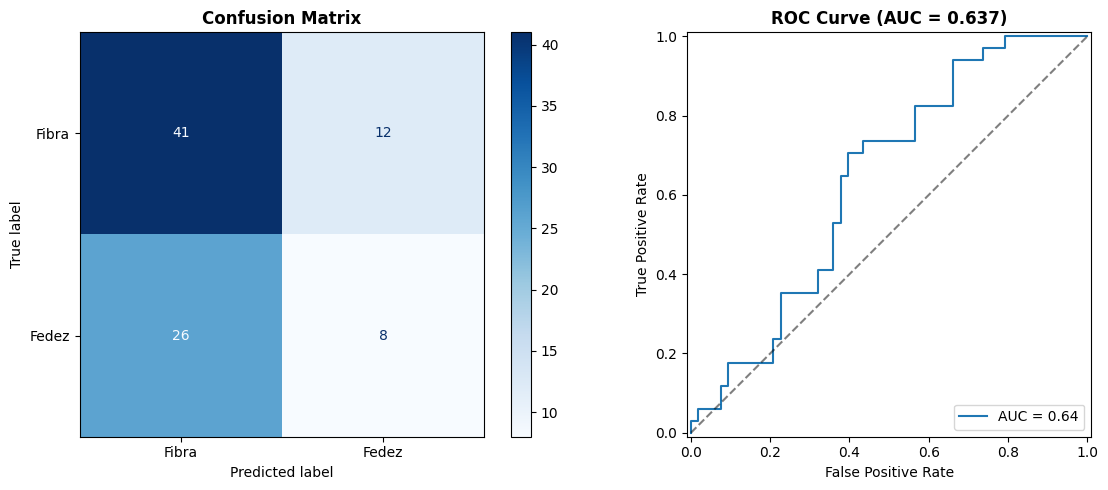

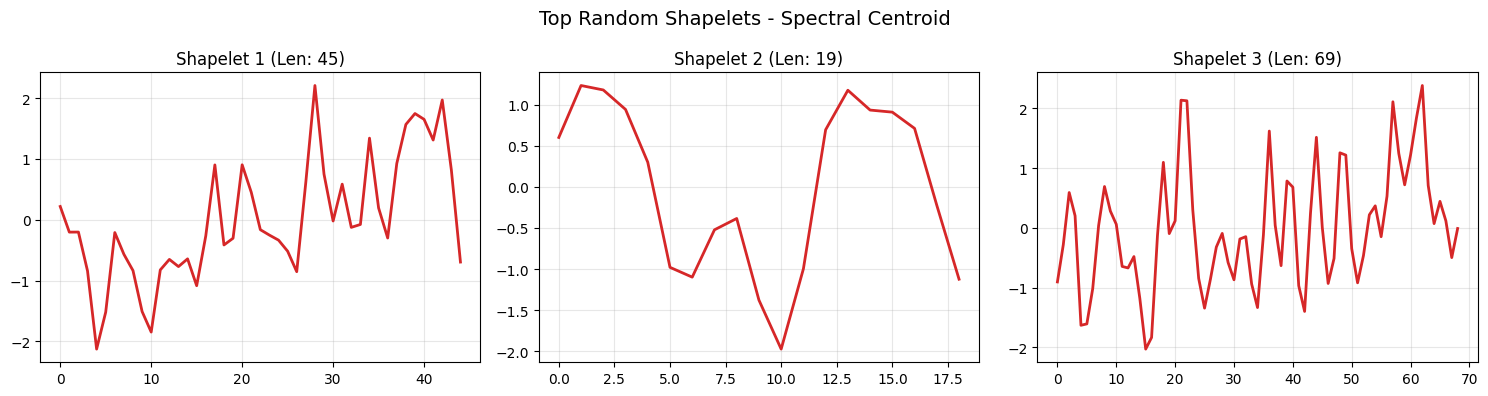


 SKTIME ANALYSIS: Bandwidth 
CLASSIFICATION METRICS
ACCURACY    : 0.6782
PRECISION   : 0.6250
RECALL      : 0.4412
F1          : 0.5172
BALANCED_ACCURACY: 0.6357
ROC_AUC     : 0.7087

              precision    recall  f1-score   support

       Fibra       0.70      0.83      0.76        53
       Fedez       0.62      0.44      0.52        34

    accuracy                           0.68        87
   macro avg       0.66      0.64      0.64        87
weighted avg       0.67      0.68      0.66        87



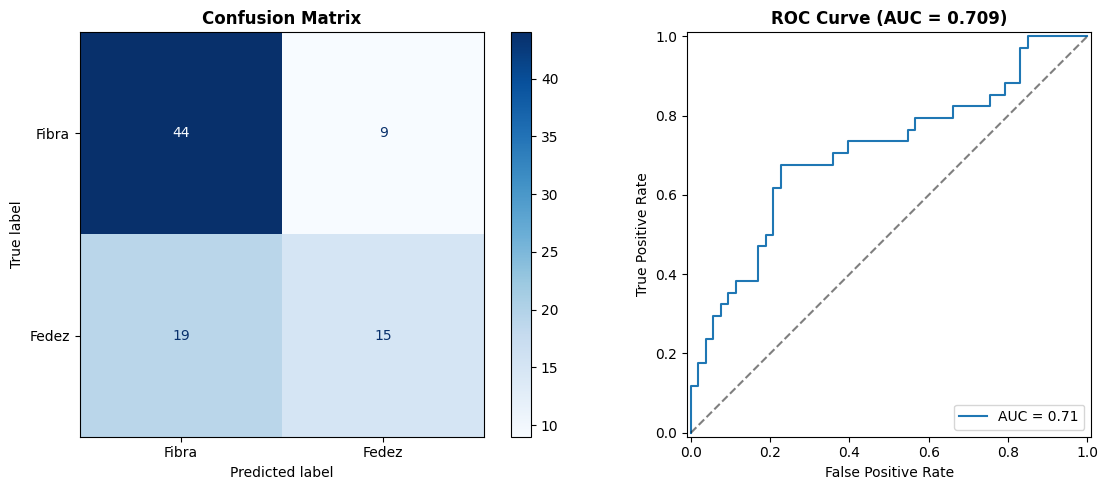

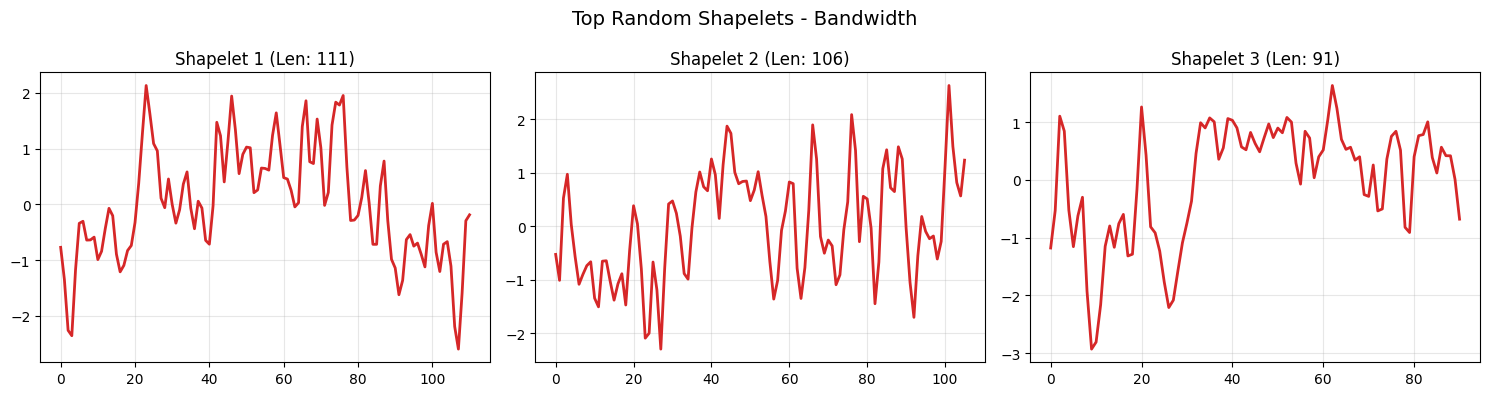


 SKTIME ANALYSIS: Rolloff 
CLASSIFICATION METRICS
ACCURACY    : 0.6782
PRECISION   : 0.6250
RECALL      : 0.4412
F1          : 0.5172
BALANCED_ACCURACY: 0.6357
ROC_AUC     : 0.6837

              precision    recall  f1-score   support

       Fibra       0.70      0.83      0.76        53
       Fedez       0.62      0.44      0.52        34

    accuracy                           0.68        87
   macro avg       0.66      0.64      0.64        87
weighted avg       0.67      0.68      0.66        87



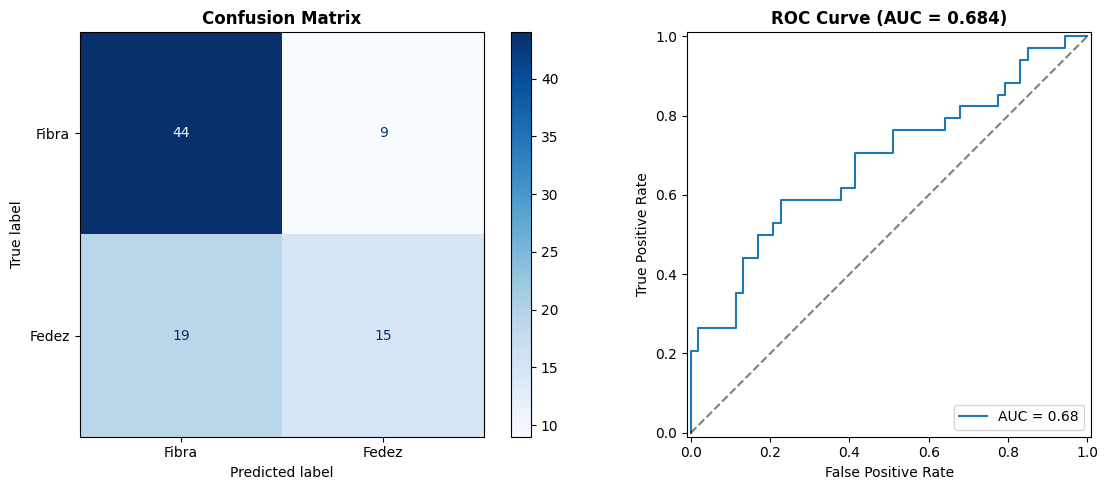

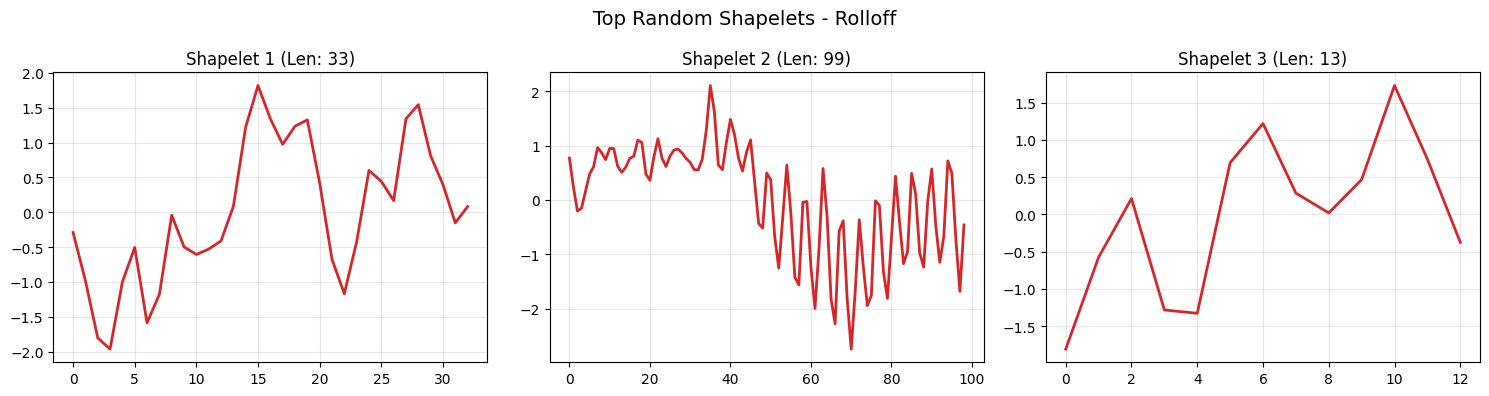


 SKTIME ANALYSIS: ZCR 
CLASSIFICATION METRICS
ACCURACY    : 0.7126
PRECISION   : 0.8462
RECALL      : 0.3235
F1          : 0.4681
BALANCED_ACCURACY: 0.6429
ROC_AUC     : 0.7575

              precision    recall  f1-score   support

       Fibra       0.69      0.96      0.80        53
       Fedez       0.85      0.32      0.47        34

    accuracy                           0.71        87
   macro avg       0.77      0.64      0.64        87
weighted avg       0.75      0.71      0.67        87



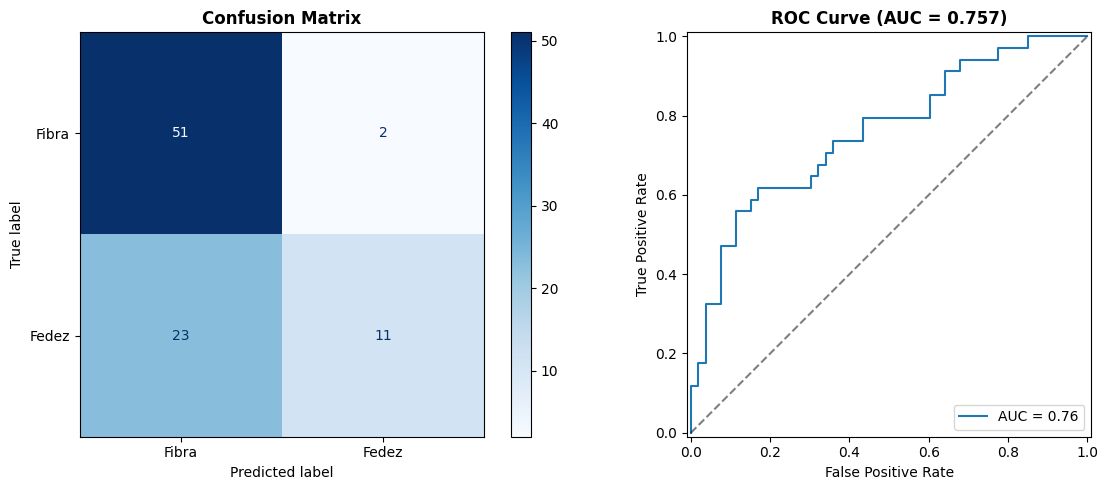

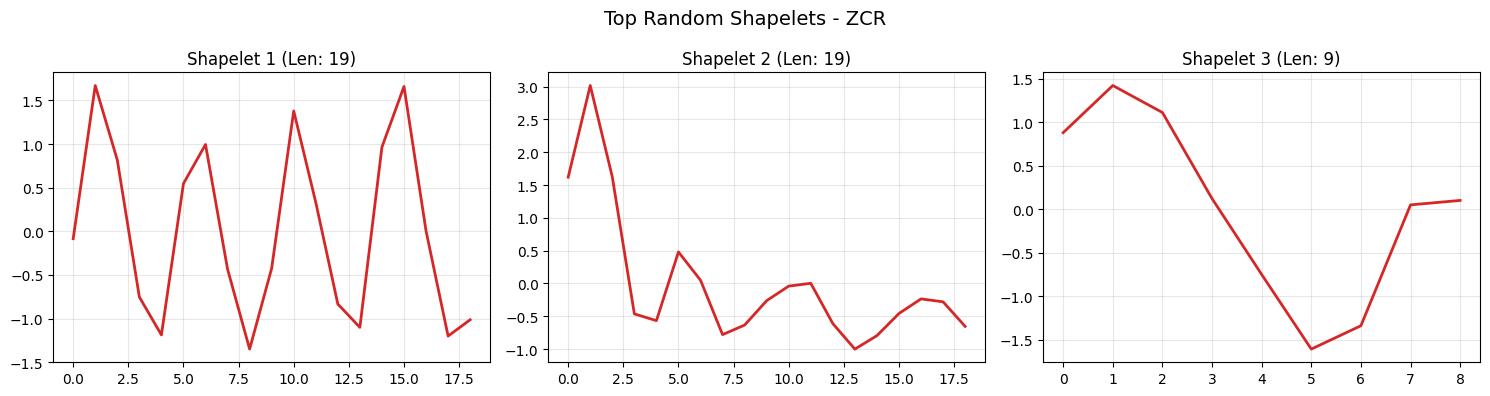

In [5]:
rf_pipeline = Pipeline([
    ('st', RandomShapeletTransform(
        n_shapelet_samples=1500, 
        max_shapelets=50,
        random_state=42,
        n_jobs=1 
    )),
    ('clf', RandomForestClassifier(random_state=42))
])

rf_params = {
    'st__max_shapelet_length': [30, 50, 100, 150],
    'clf__n_estimators': [100, 200, 300],
    'clf__max_depth': [5, 10, 20, None]
}

rf_results = run_shapelet_pipeline(
    X_train, y_train, X_test, y_test, 
    feature_names=['RMS', 'Spectral Centroid', 'Bandwidth', 'Rolloff', 'ZCR'],
    base_pipeline=rf_pipeline,
    param_grid=rf_params
)

plot_sktime_results(rf_results)

### SVC

Processing feature: RMS...


Processing feature: Spectral Centroid...
Processing feature: Bandwidth...
Processing feature: Rolloff...
Processing feature: ZCR...

 SKTIME ANALYSIS: RMS 
CLASSIFICATION METRICS
ACCURACY    : 0.6782
PRECISION   : 0.6154
RECALL      : 0.4706
F1          : 0.5333
BALANCED_ACCURACY: 0.6410
ROC_AUC     : 0.7253

              precision    recall  f1-score   support

       Fibra       0.70      0.81      0.75        53
       Fedez       0.62      0.47      0.53        34

    accuracy                           0.68        87
   macro avg       0.66      0.64      0.64        87
weighted avg       0.67      0.68      0.67        87



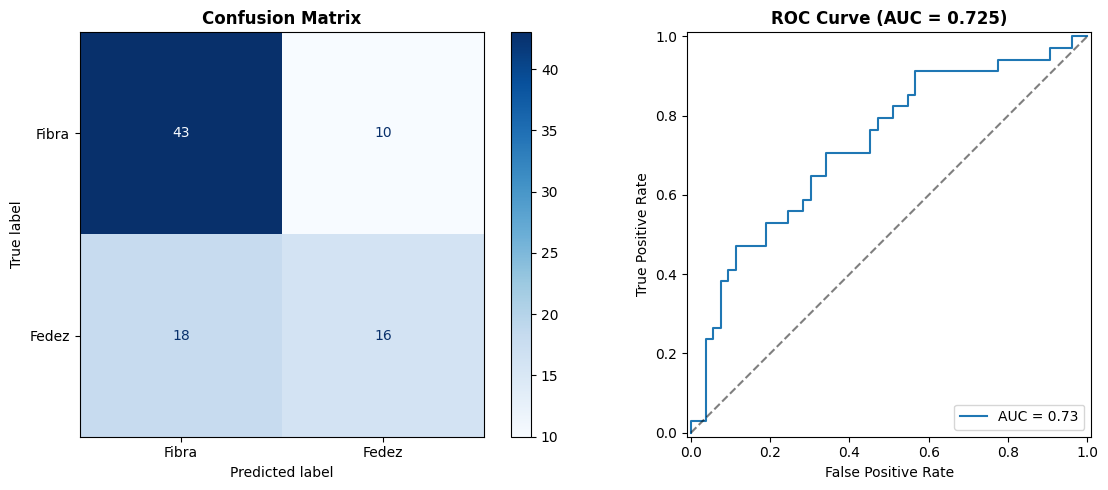

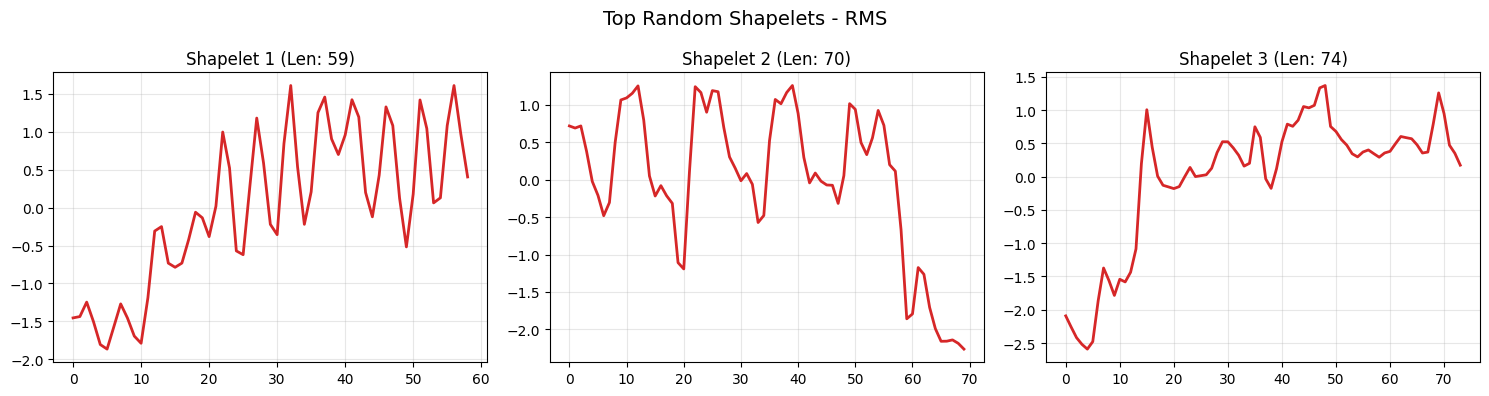


 SKTIME ANALYSIS: Spectral Centroid 
CLASSIFICATION METRICS
ACCURACY    : 0.5287
PRECISION   : 0.3793
RECALL      : 0.3235
F1          : 0.3492
BALANCED_ACCURACY: 0.4920
ROC_AUC     : 0.5166

              precision    recall  f1-score   support

       Fibra       0.60      0.66      0.63        53
       Fedez       0.38      0.32      0.35        34

    accuracy                           0.53        87
   macro avg       0.49      0.49      0.49        87
weighted avg       0.52      0.53      0.52        87



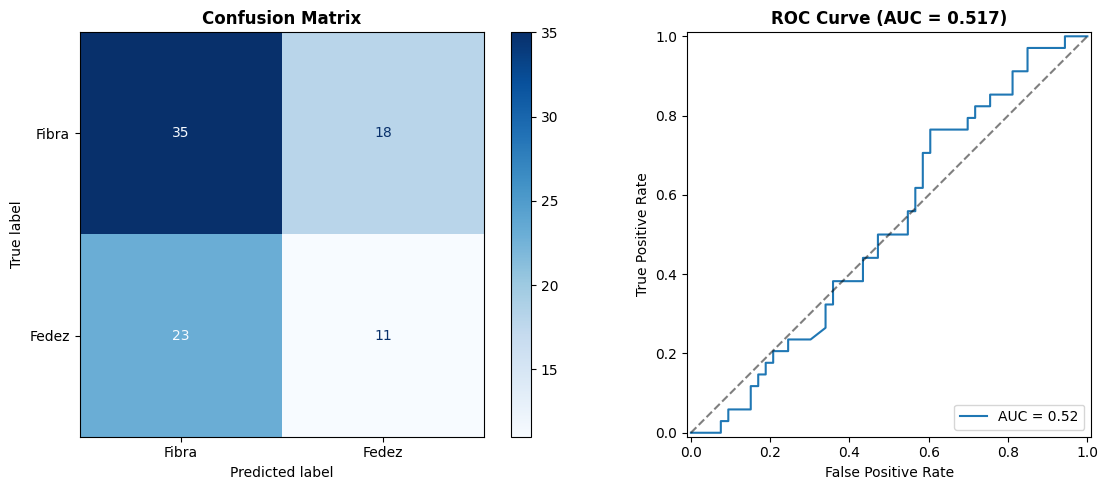

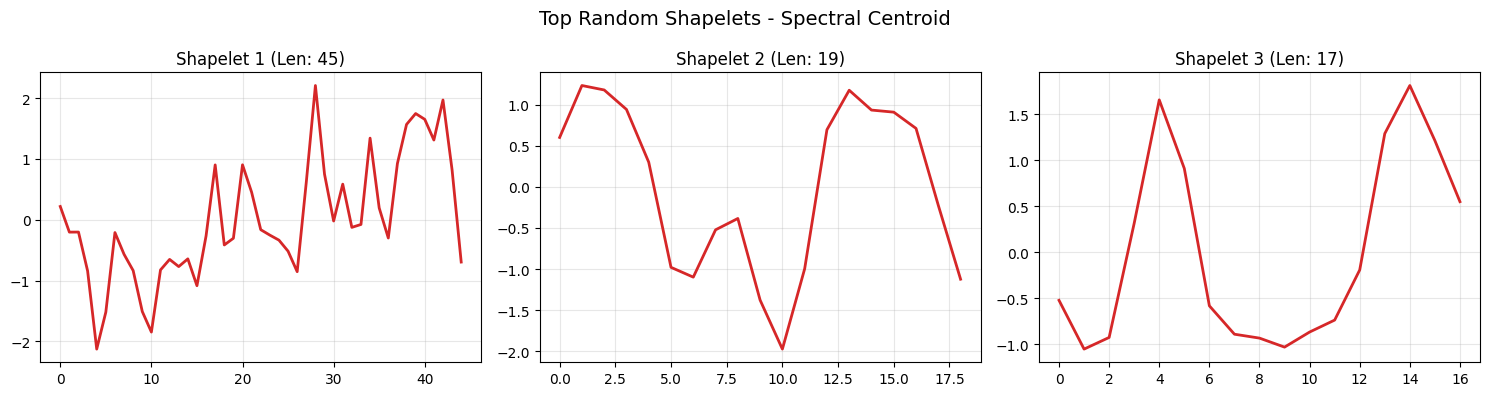


 SKTIME ANALYSIS: Bandwidth 
CLASSIFICATION METRICS
ACCURACY    : 0.6552
PRECISION   : 0.6000
RECALL      : 0.3529
F1          : 0.4444
BALANCED_ACCURACY: 0.6010
ROC_AUC     : 0.5649

              precision    recall  f1-score   support

       Fibra       0.67      0.85      0.75        53
       Fedez       0.60      0.35      0.44        34

    accuracy                           0.66        87
   macro avg       0.64      0.60      0.60        87
weighted avg       0.64      0.66      0.63        87



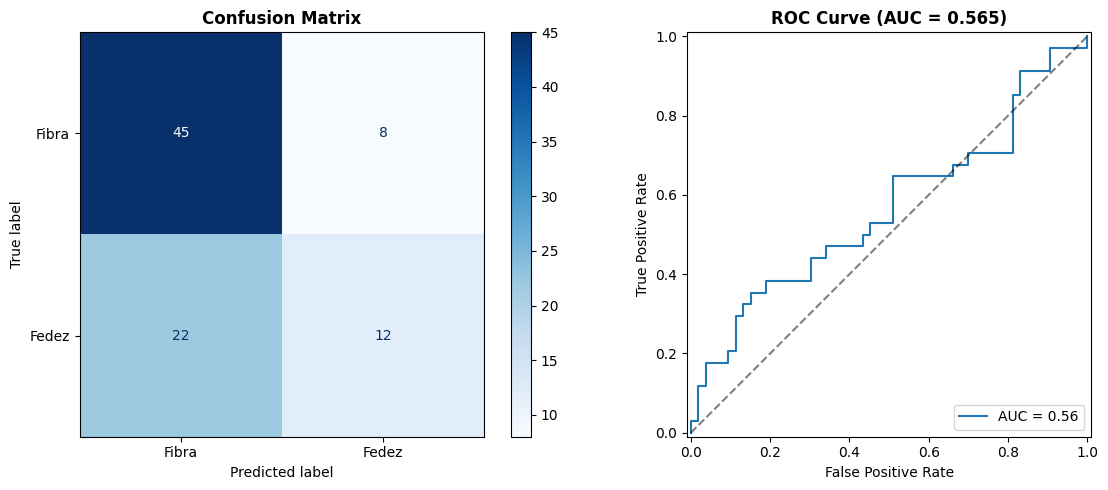

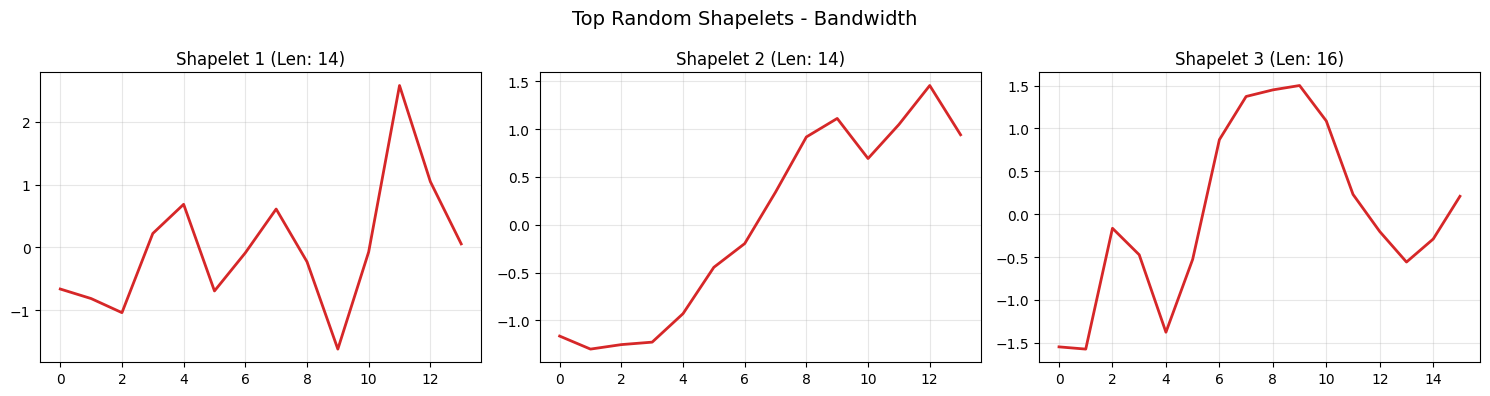


 SKTIME ANALYSIS: Rolloff 
CLASSIFICATION METRICS
ACCURACY    : 0.5862
PRECISION   : 0.4583
RECALL      : 0.3235
F1          : 0.3793
BALANCED_ACCURACY: 0.5391
ROC_AUC     : 0.5760

              precision    recall  f1-score   support

       Fibra       0.63      0.75      0.69        53
       Fedez       0.46      0.32      0.38        34

    accuracy                           0.59        87
   macro avg       0.55      0.54      0.53        87
weighted avg       0.57      0.59      0.57        87



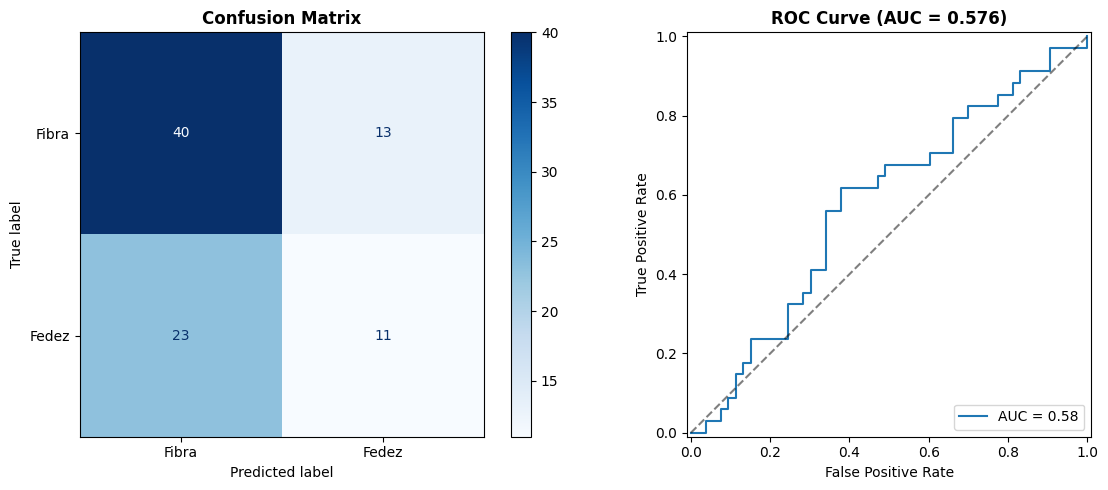

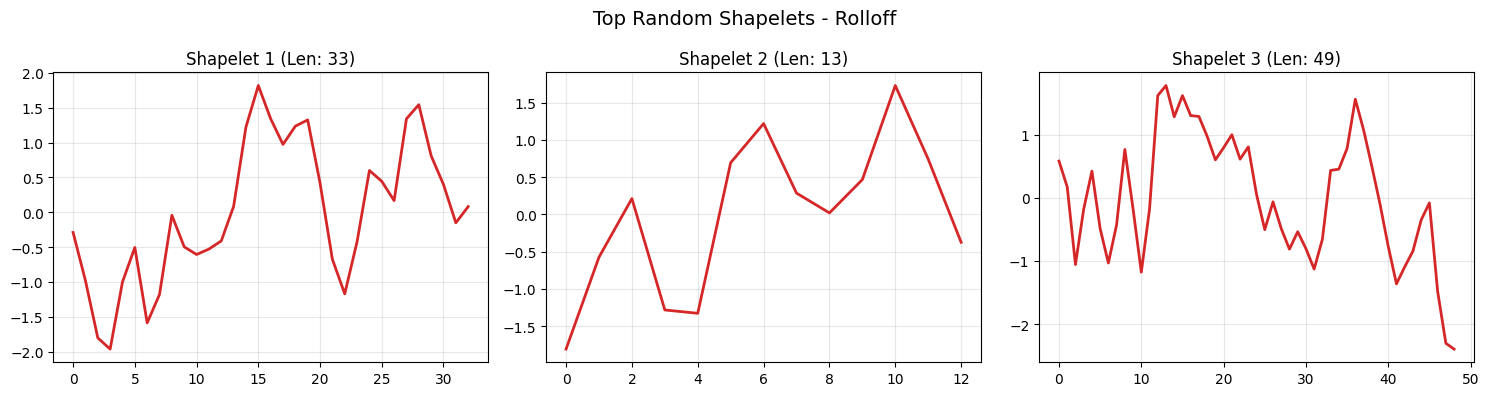


 SKTIME ANALYSIS: ZCR 
CLASSIFICATION METRICS
ACCURACY    : 0.6092
PRECISION   : 0.5000
RECALL      : 0.4118
F1          : 0.4516
BALANCED_ACCURACY: 0.5738
ROC_AUC     : 0.6249

              precision    recall  f1-score   support

       Fibra       0.66      0.74      0.70        53
       Fedez       0.50      0.41      0.45        34

    accuracy                           0.61        87
   macro avg       0.58      0.57      0.57        87
weighted avg       0.60      0.61      0.60        87



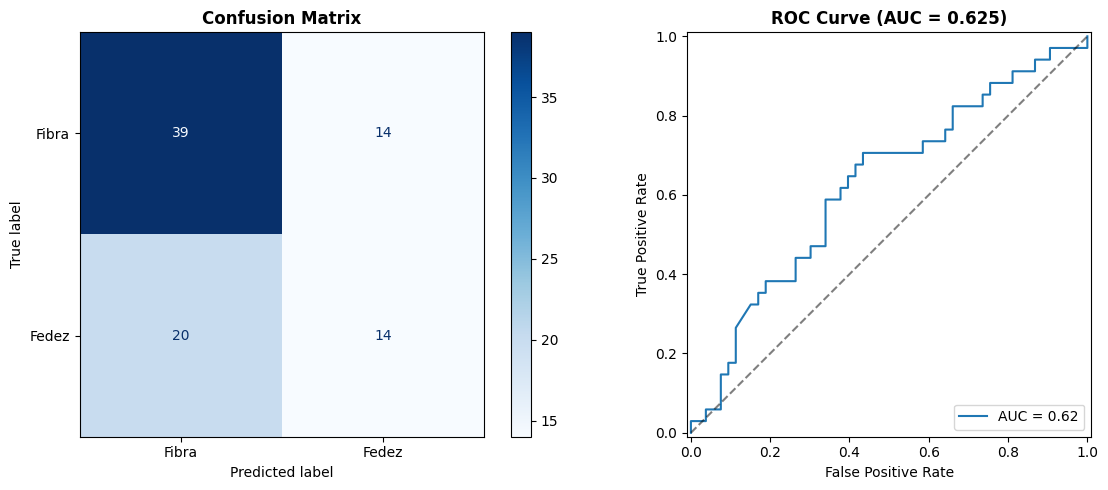

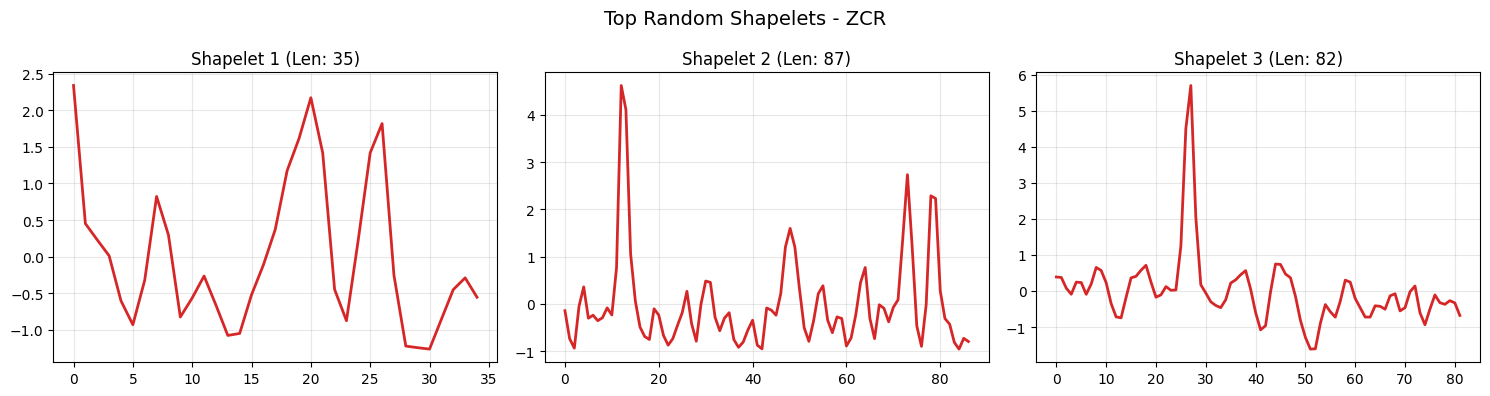

In [6]:
from sklearn.svm import SVC

# Define Pipeline
svm_pipeline = Pipeline([
    ('st', RandomShapeletTransform(n_shapelet_samples=1500, max_shapelets=50, random_state=42, n_jobs=1)),
    ('clf', SVC(probability=True, random_state=42)) # probability=True is needed for probs[:, 1]
])

# Define Grid
svm_params = {
    'st__max_shapelet_length': [30, 50, 100, 150],
    'clf__C': [0.01, 0.1, 0.5, 1, 5, 10],          # Regularization parameter
    'clf__kernel': ['linear', 'rbf'] # Type of decision boundary
}

# Run
svm_results = run_shapelet_pipeline(X_train, y_train, X_test, y_test, feature_names, svm_pipeline, svm_params)
plot_sktime_results(svm_results)

### KNN

Processing feature: RMS...
Processing feature: Spectral Centroid...
Processing feature: Bandwidth...
Processing feature: Rolloff...
Processing feature: ZCR...

 SKTIME ANALYSIS: RMS 
CLASSIFICATION METRICS
ACCURACY    : 0.7126
PRECISION   : 0.7143
RECALL      : 0.4412
F1          : 0.5455
BALANCED_ACCURACY: 0.6640
ROC_AUC     : 0.7422

              precision    recall  f1-score   support

       Fibra       0.71      0.89      0.79        53
       Fedez       0.71      0.44      0.55        34

    accuracy                           0.71        87
   macro avg       0.71      0.66      0.67        87
weighted avg       0.71      0.71      0.69        87



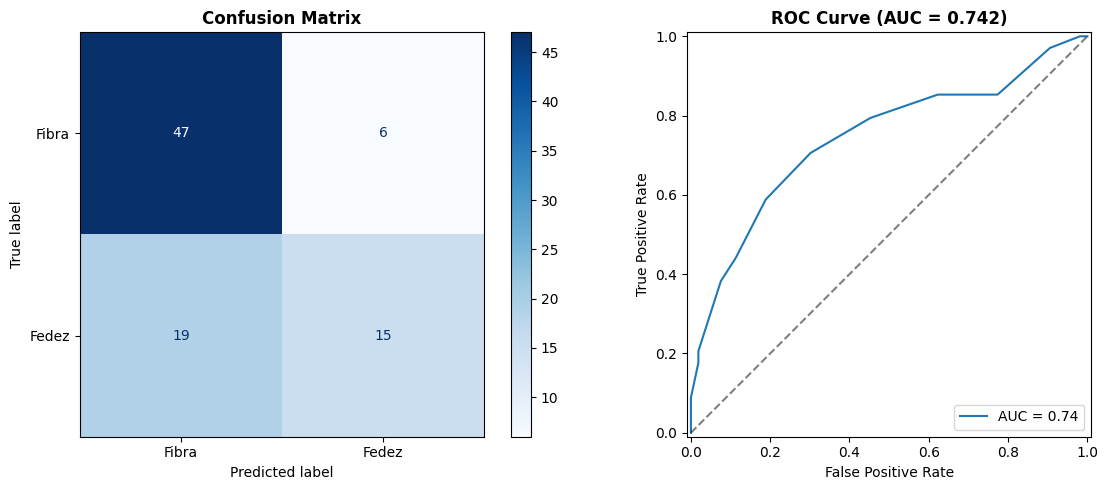

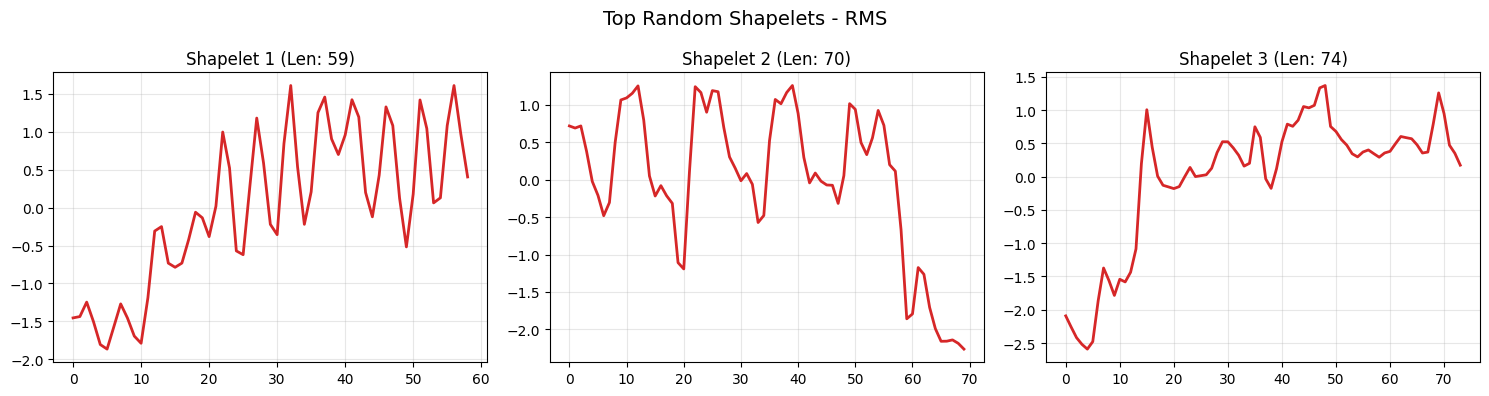


 SKTIME ANALYSIS: Spectral Centroid 
CLASSIFICATION METRICS
ACCURACY    : 0.5747
PRECISION   : 0.4667
RECALL      : 0.6176
F1          : 0.5316
BALANCED_ACCURACY: 0.5824
ROC_AUC     : 0.6204

              precision    recall  f1-score   support

       Fibra       0.69      0.55      0.61        53
       Fedez       0.47      0.62      0.53        34

    accuracy                           0.57        87
   macro avg       0.58      0.58      0.57        87
weighted avg       0.60      0.57      0.58        87



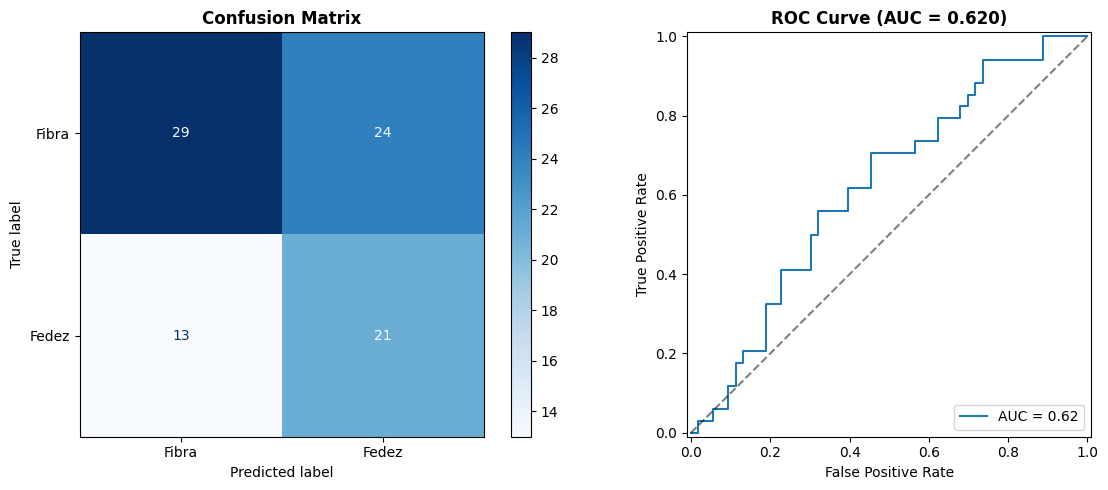

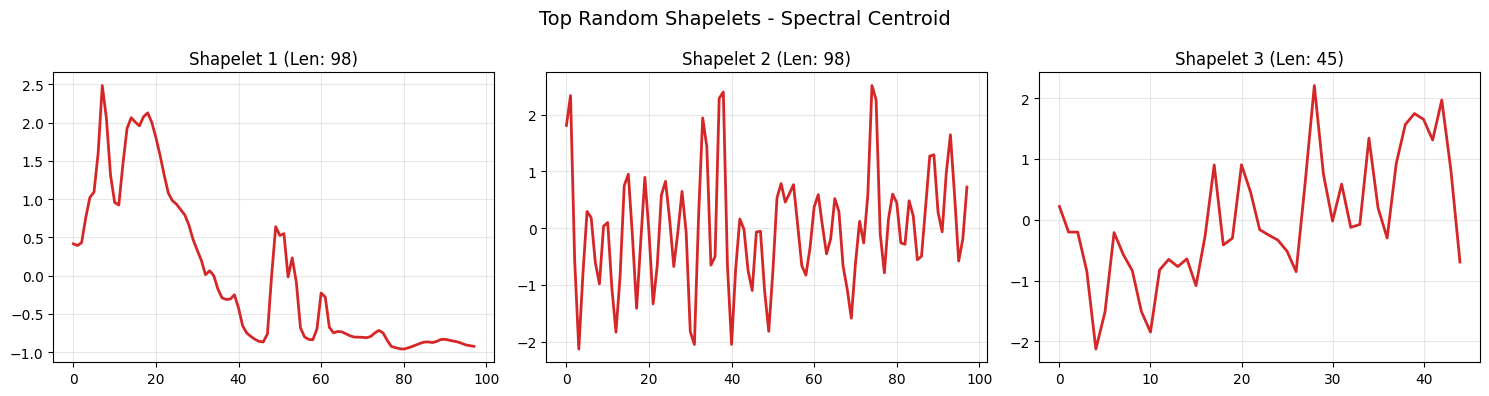


 SKTIME ANALYSIS: Bandwidth 
CLASSIFICATION METRICS
ACCURACY    : 0.6897
PRECISION   : 0.6296
RECALL      : 0.5000
F1          : 0.5574
BALANCED_ACCURACY: 0.6557
ROC_AUC     : 0.7175

              precision    recall  f1-score   support

       Fibra       0.72      0.81      0.76        53
       Fedez       0.63      0.50      0.56        34

    accuracy                           0.69        87
   macro avg       0.67      0.66      0.66        87
weighted avg       0.68      0.69      0.68        87



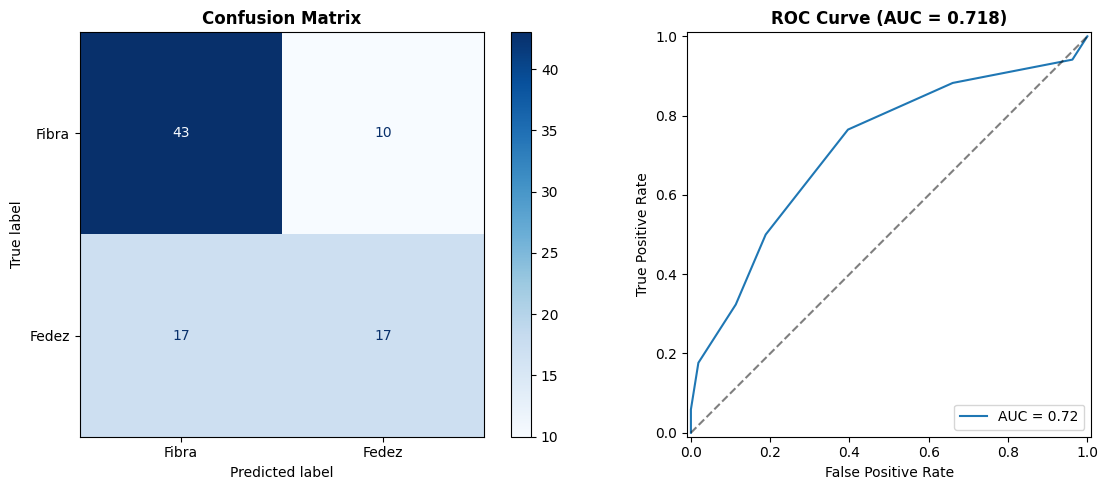

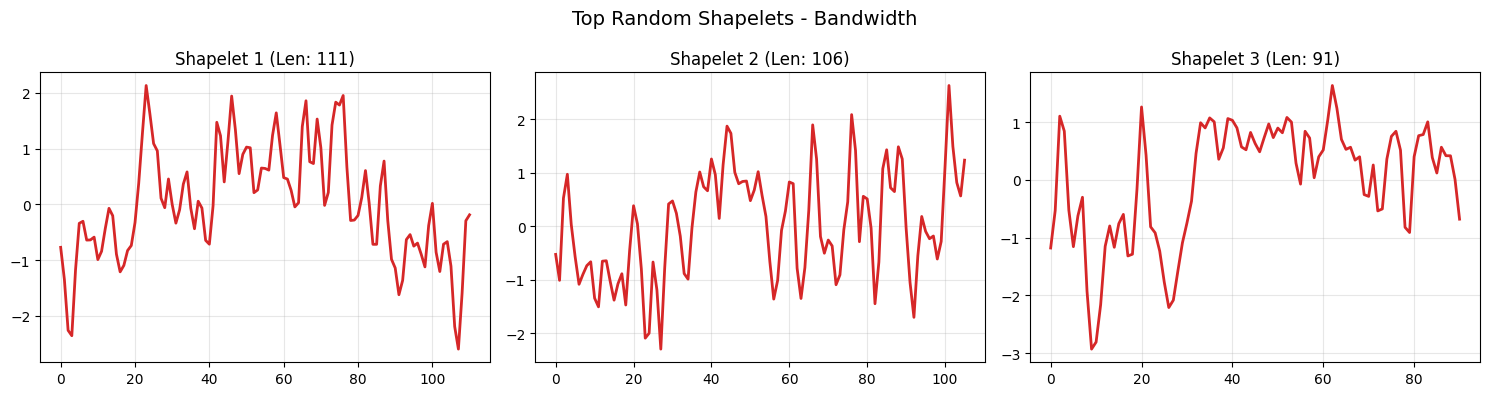


 SKTIME ANALYSIS: Rolloff 
CLASSIFICATION METRICS
ACCURACY    : 0.6552
PRECISION   : 0.5714
RECALL      : 0.4706
F1          : 0.5161
BALANCED_ACCURACY: 0.6221
ROC_AUC     : 0.7003

              precision    recall  f1-score   support

       Fibra       0.69      0.77      0.73        53
       Fedez       0.57      0.47      0.52        34

    accuracy                           0.66        87
   macro avg       0.63      0.62      0.62        87
weighted avg       0.65      0.66      0.65        87



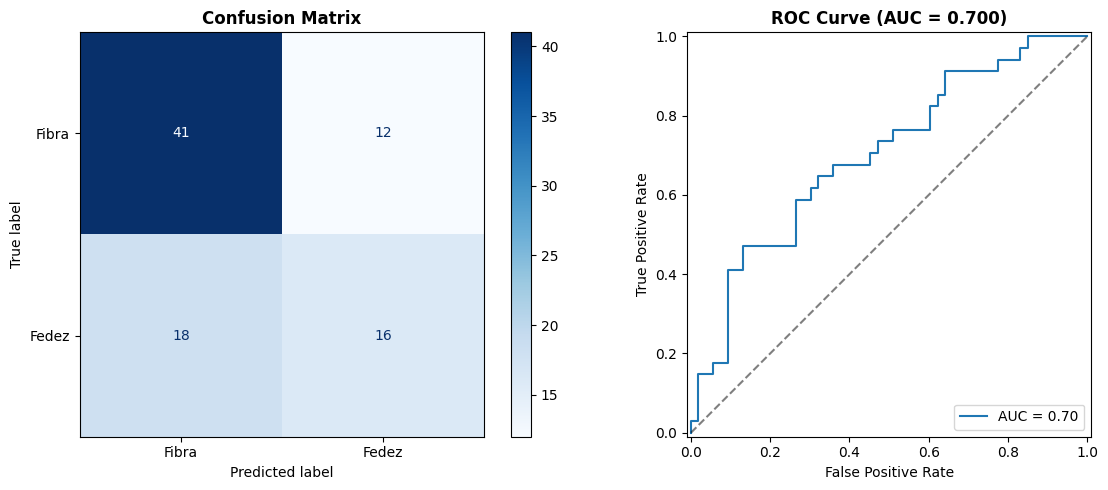

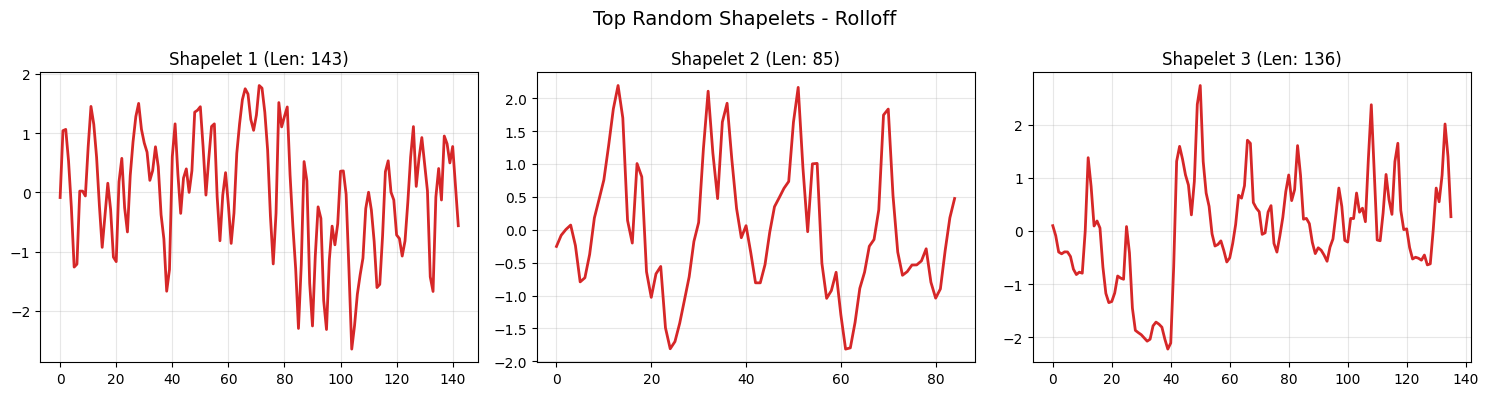


 SKTIME ANALYSIS: ZCR 
CLASSIFICATION METRICS
ACCURACY    : 0.6667
PRECISION   : 0.5758
RECALL      : 0.5588
F1          : 0.5672
BALANCED_ACCURACY: 0.6473
ROC_AUC     : 0.7400

              precision    recall  f1-score   support

       Fibra       0.72      0.74      0.73        53
       Fedez       0.58      0.56      0.57        34

    accuracy                           0.67        87
   macro avg       0.65      0.65      0.65        87
weighted avg       0.66      0.67      0.67        87



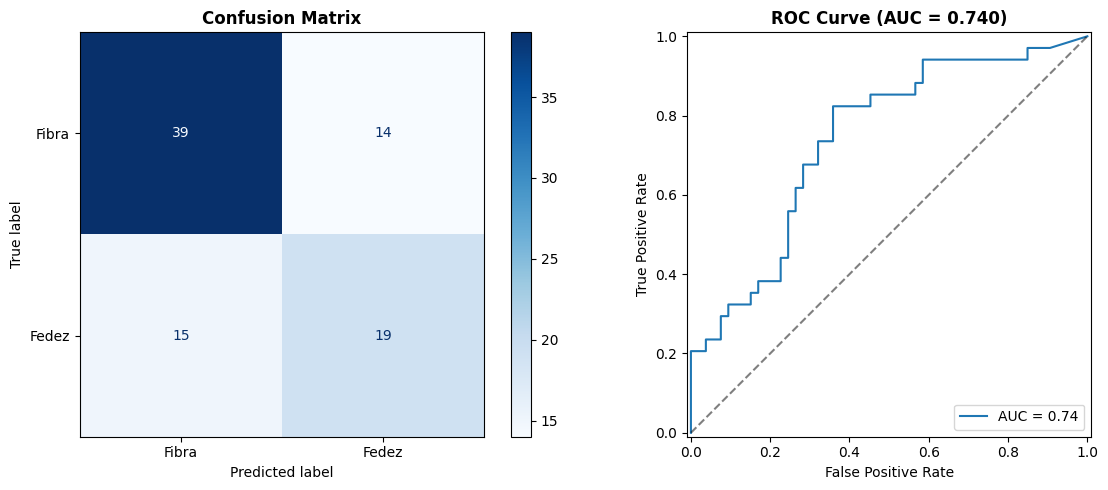

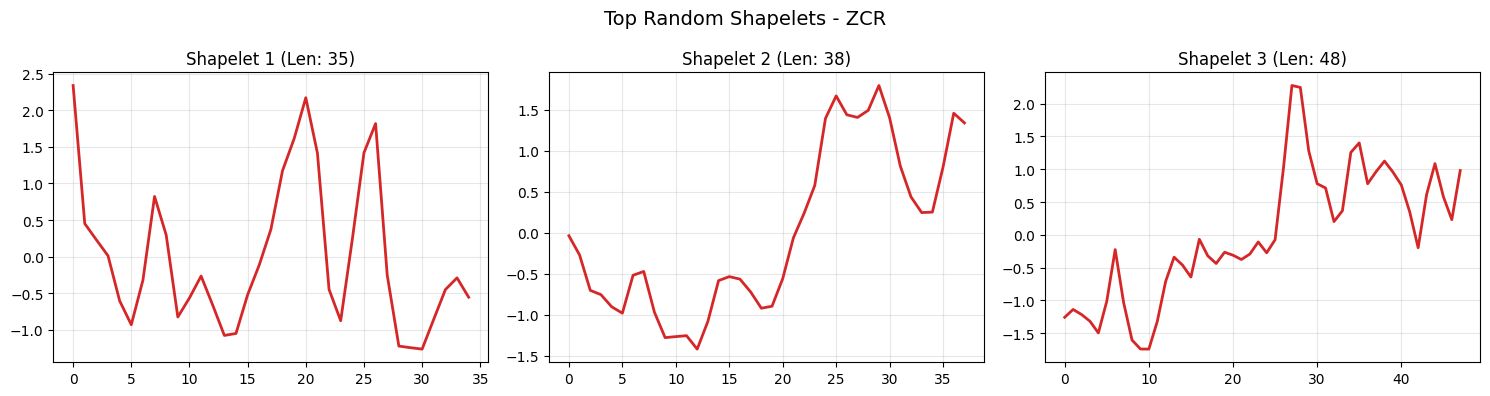

In [7]:
from sklearn.neighbors import KNeighborsClassifier

# Define Pipeline
knn_pipeline = Pipeline([
    ('st', RandomShapeletTransform(n_shapelet_samples=1500, max_shapelets=50, random_state=42, n_jobs=1)),
    ('clf', KNeighborsClassifier())
])

# Define Grid
knn_params = {
    'st__max_shapelet_length': [30, 50, 100, 150],
    'clf__n_neighbors': [3, 5, 7, 10, 15],
    'clf__weights': ['uniform', 'distance']
}

# Run
knn_results = run_shapelet_pipeline(X_train, y_train, X_test, y_test, feature_names, knn_pipeline, knn_params)
plot_sktime_results(knn_results)

### XGBoost

Processing feature: RMS...
Processing feature: Spectral Centroid...
Processing feature: Bandwidth...
Processing feature: Rolloff...
Processing feature: ZCR...

 SKTIME ANALYSIS: RMS 
CLASSIFICATION METRICS
ACCURACY    : 0.6552
PRECISION   : 0.5769
RECALL      : 0.4412
F1          : 0.5000
BALANCED_ACCURACY: 0.6168
ROC_AUC     : 0.6565

              precision    recall  f1-score   support

       Fibra       0.69      0.79      0.74        53
       Fedez       0.58      0.44      0.50        34

    accuracy                           0.66        87
   macro avg       0.63      0.62      0.62        87
weighted avg       0.64      0.66      0.64        87



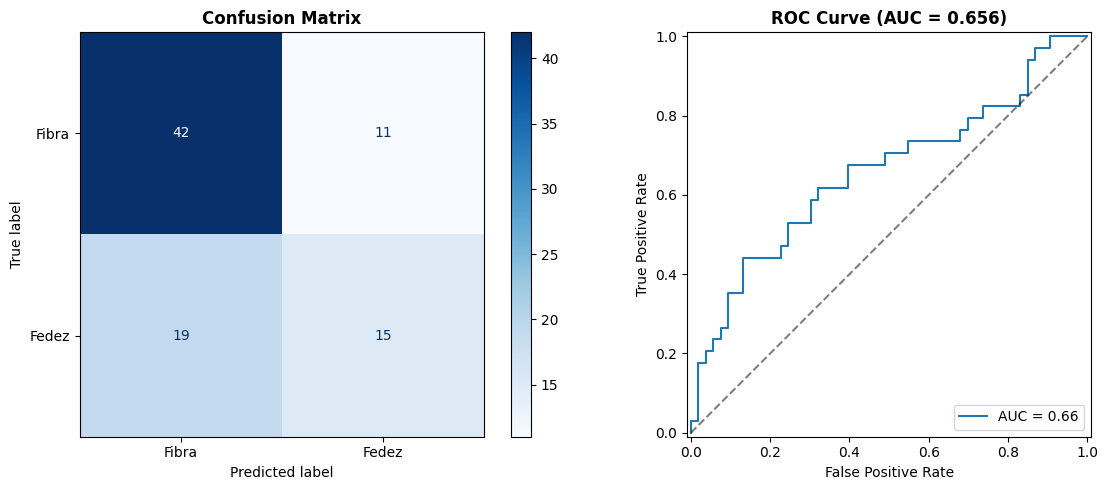

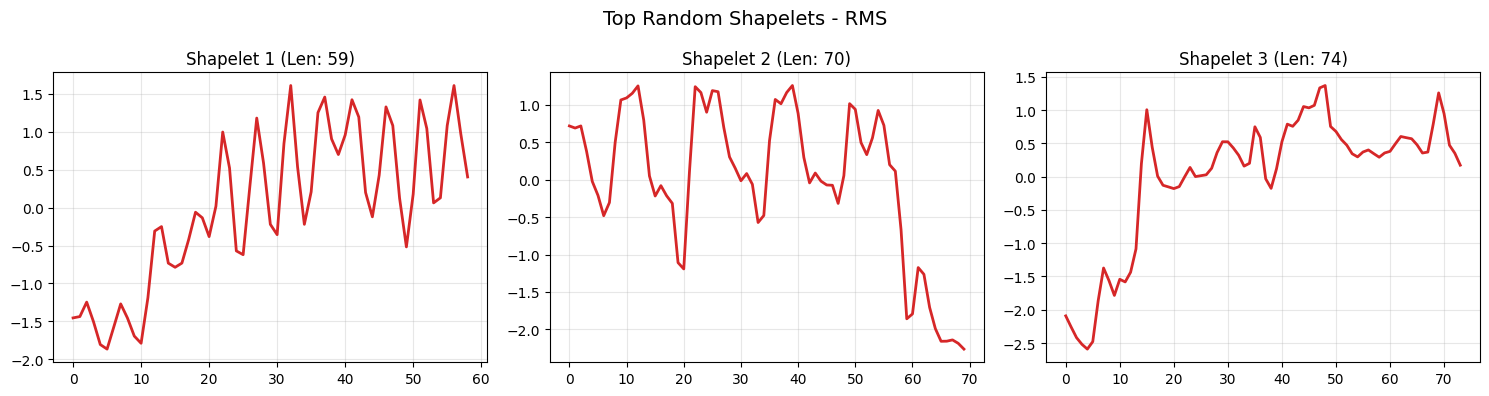


 SKTIME ANALYSIS: Spectral Centroid 
CLASSIFICATION METRICS
ACCURACY    : 0.5287
PRECISION   : 0.3600
RECALL      : 0.2647
F1          : 0.3051
BALANCED_ACCURACY: 0.4814
ROC_AUC     : 0.5272

              precision    recall  f1-score   support

       Fibra       0.60      0.70      0.64        53
       Fedez       0.36      0.26      0.31        34

    accuracy                           0.53        87
   macro avg       0.48      0.48      0.47        87
weighted avg       0.50      0.53      0.51        87



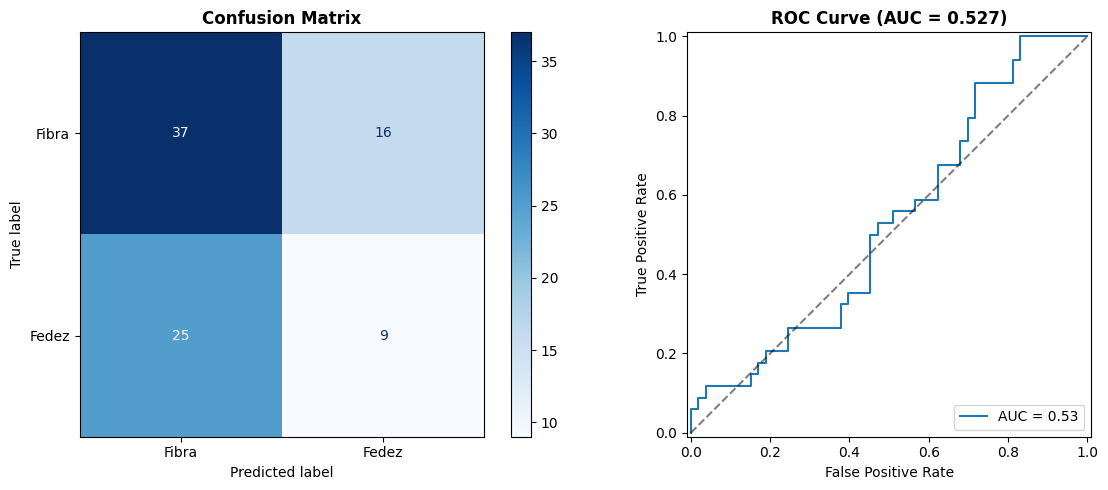

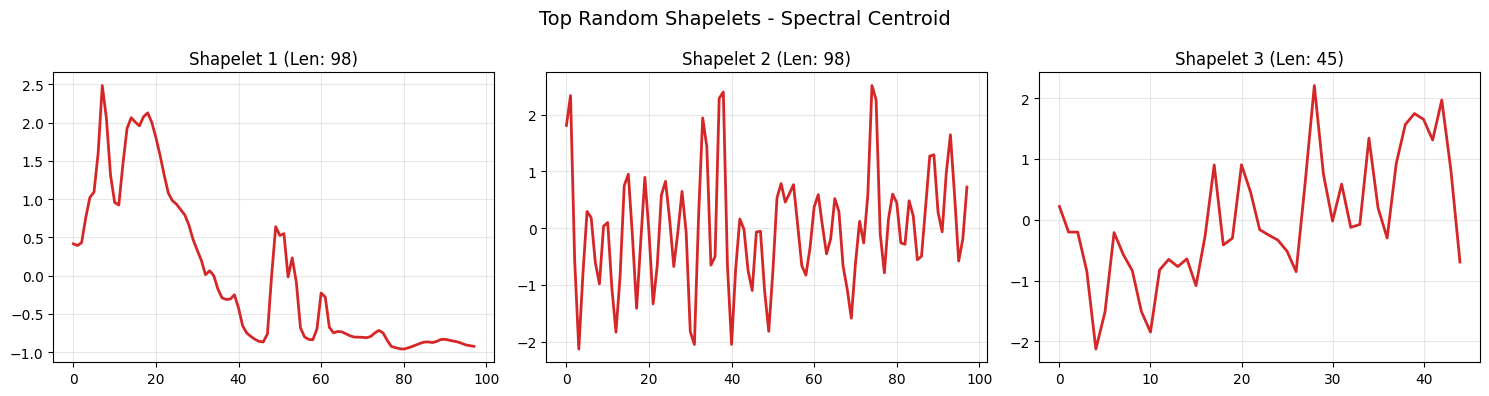


 SKTIME ANALYSIS: Bandwidth 
CLASSIFICATION METRICS
ACCURACY    : 0.6437
PRECISION   : 0.6154
RECALL      : 0.2353
F1          : 0.3404
BALANCED_ACCURACY: 0.5705
ROC_AUC     : 0.6354

              precision    recall  f1-score   support

       Fibra       0.65      0.91      0.76        53
       Fedez       0.62      0.24      0.34        34

    accuracy                           0.64        87
   macro avg       0.63      0.57      0.55        87
weighted avg       0.64      0.64      0.59        87



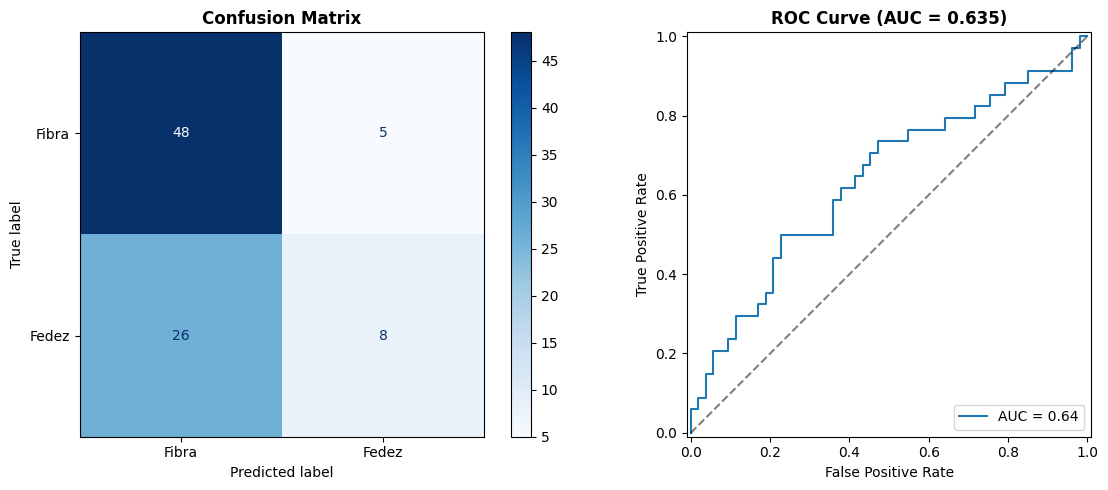

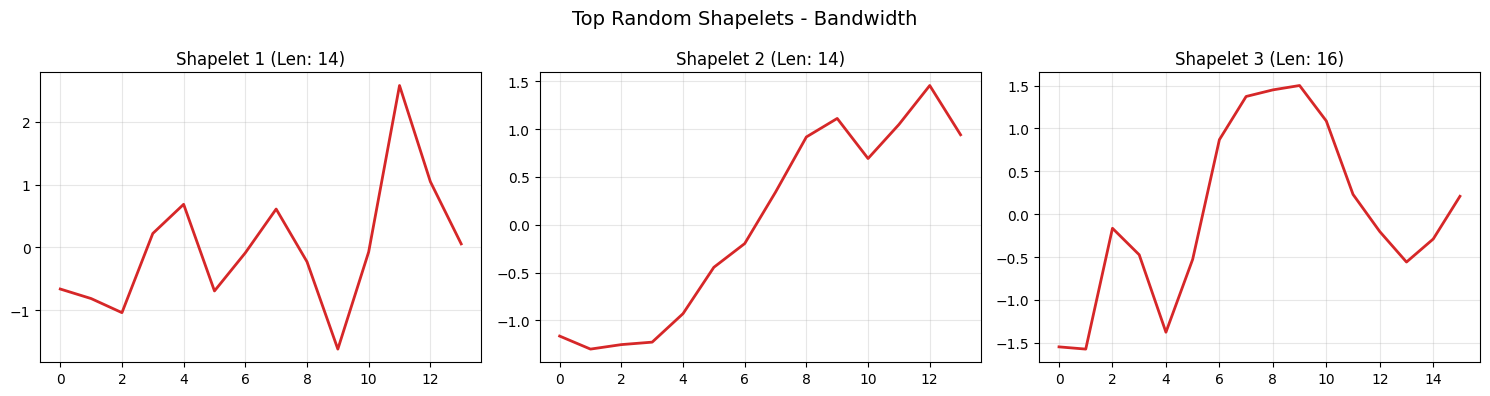


 SKTIME ANALYSIS: Rolloff 
CLASSIFICATION METRICS
ACCURACY    : 0.6322
PRECISION   : 0.5333
RECALL      : 0.4706
F1          : 0.5000
BALANCED_ACCURACY: 0.6032
ROC_AUC     : 0.6337

              precision    recall  f1-score   support

       Fibra       0.68      0.74      0.71        53
       Fedez       0.53      0.47      0.50        34

    accuracy                           0.63        87
   macro avg       0.61      0.60      0.60        87
weighted avg       0.63      0.63      0.63        87



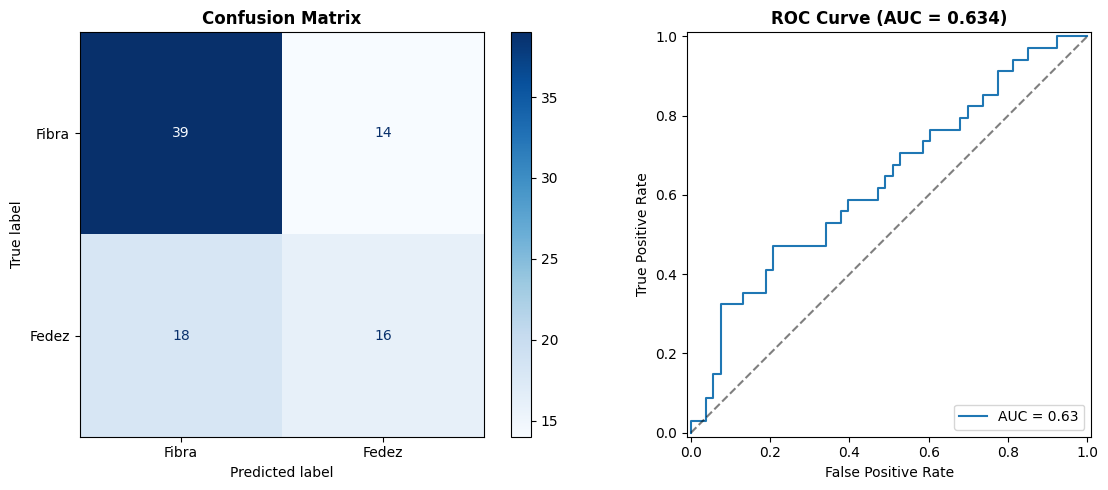

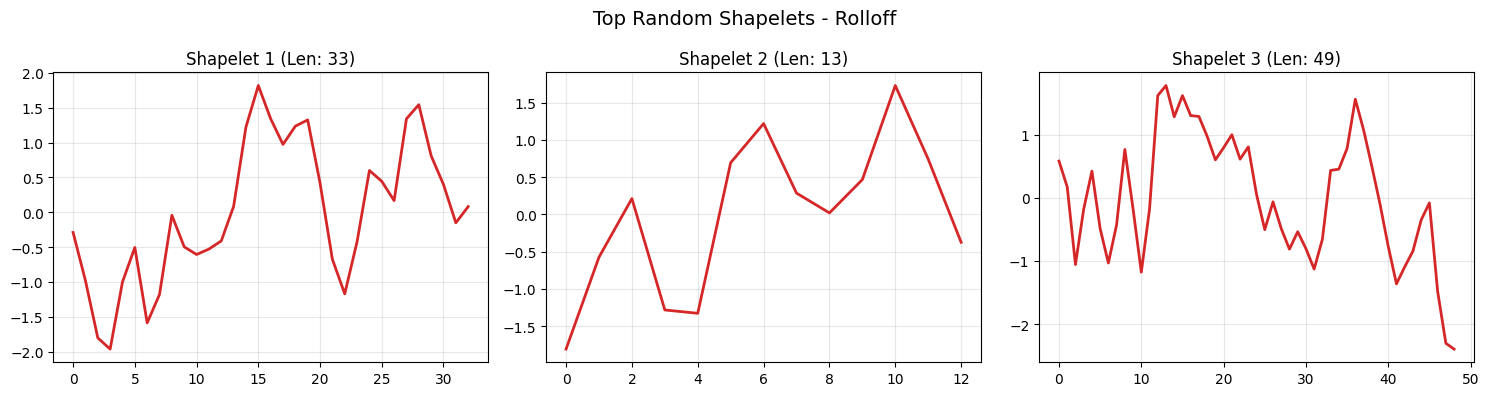


 SKTIME ANALYSIS: ZCR 
CLASSIFICATION METRICS
ACCURACY    : 0.6667
PRECISION   : 0.6087
RECALL      : 0.4118
F1          : 0.4912
BALANCED_ACCURACY: 0.6210
ROC_AUC     : 0.7508

              precision    recall  f1-score   support

       Fibra       0.69      0.83      0.75        53
       Fedez       0.61      0.41      0.49        34

    accuracy                           0.67        87
   macro avg       0.65      0.62      0.62        87
weighted avg       0.66      0.67      0.65        87



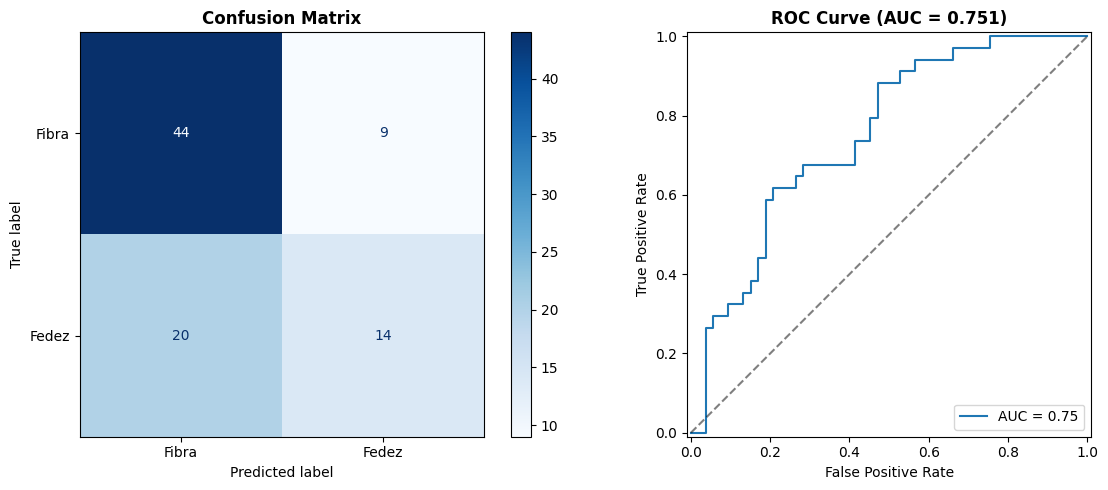

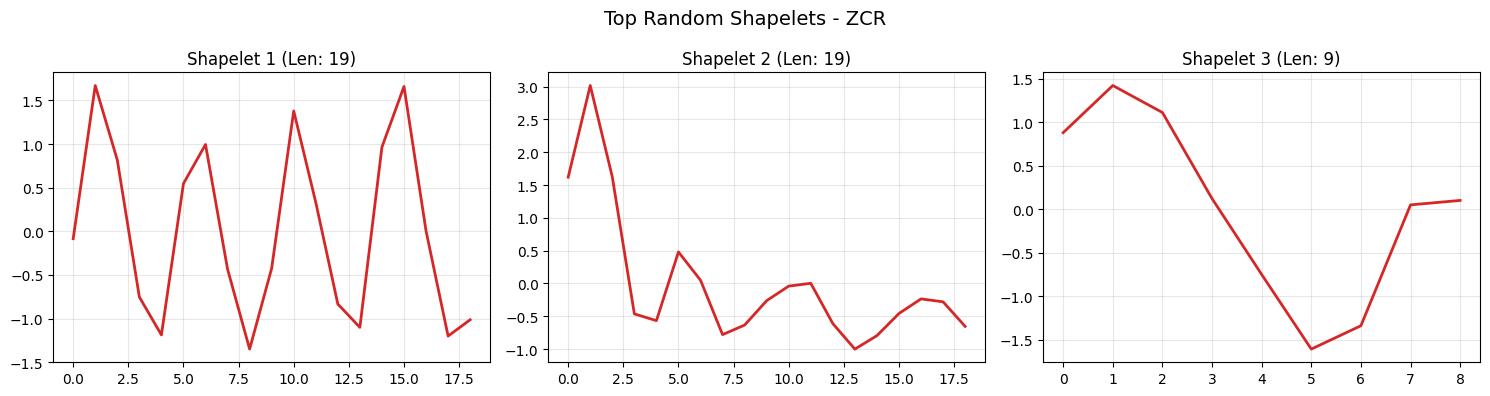

In [8]:
from xgboost import XGBClassifier

# Define Pipeline
xgb_pipeline = Pipeline([
    ('st', RandomShapeletTransform(n_shapelet_samples=1500, max_shapelets=50, random_state=42, n_jobs=1)),
    ('clf', XGBClassifier(eval_metric='logloss', random_state=42))
])

# Define Grid
xgb_params = {
    'st__max_shapelet_length': [30, 50, 100, 150],
    'clf__n_estimators': [100, 200, 300],
    'clf__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'clf__max_depth': [3, 5, 7, 10]
}

# Run
xgb_results = run_shapelet_pipeline(X_train, y_train, X_test, y_test, feature_names, xgb_pipeline, xgb_params)
plot_sktime_results(xgb_results)

## Shapelet Learning

In [ ]:
search_params = [
    {'shape_size': 30, 'emb_dim': 128, 'sparse_rate': 0.5},
    {'shape_size': 60, 'emb_dim': 256, 'sparse_rate': 0.3},
    {'shape_size': 40, 'emb_dim': 128, 'sparse_rate': 0.8},
]

results = optimize_shapelets(
    X_train, y_train, 
    X_test, y_test,
    search_configs=search_params,
    cv=cv,
    input_format='NLC', 
    epochs=50,
    batch_size=32,
    lr=0.001,
    verbose=1,
    patience=20,
    scoring_func=balanced_accuracy_score
)

best_clf = results['model'] 
print(f"Best Test Score: {results['test_score']:.4f}")

best_clf.eval()
device = next(best_clf.parameters()).device

X_tensor = torch.tensor(X_test.transpose(0, 2, 1), dtype=torch.float32).to(device)
with torch.no_grad():
    probs = F.softmax(best_clf(X_tensor)[0], dim=1).cpu().numpy()

--- SoftShapeNet Optimization over 1 configurations ---
CV: StratifiedKFold(n_splits=3, random_state=42, shuffle=True)
Device: mps, Seq Len: 1239, Channels: 5

[1/1] Config: {'shape_size': 30, 'emb_dim': 256}
  Fold 1: Score=0.6595 (Ep: 19)
  Fold 2: Score=0.6532 (Ep: 25)
  Fold 3: Score=0.6353 (Ep: 15)
  Avg F1 Score: 0.6493, Avg Best Epoch: 19

--- Retraining best config on full training set for 19 epochs ---
Best Config: {'shape_size': 30, 'emb_dim': 256, 'optimal_epochs': 19}, CV Avg Score: 0.6493
  Epoch 10/19, Loss: 0.5827

--- Final Test Set Score: 0.6640 ---
Best Test Score: 0.6640


CLASSIFICATION METRICS
ACCURACY    : 0.7126
PRECISION   : 0.7143
RECALL      : 0.4412
F1          : 0.5455
BALANCED_ACCURACY: 0.6640
ROC_AUC     : 0.7725

              precision    recall  f1-score   support

 Fabri Fibra       0.71      0.89      0.79        53
       Fedez       0.71      0.44      0.55        34

    accuracy                           0.71        87
   macro avg       0.71      0.66      0.67        87
weighted avg       0.71      0.71      0.69        87



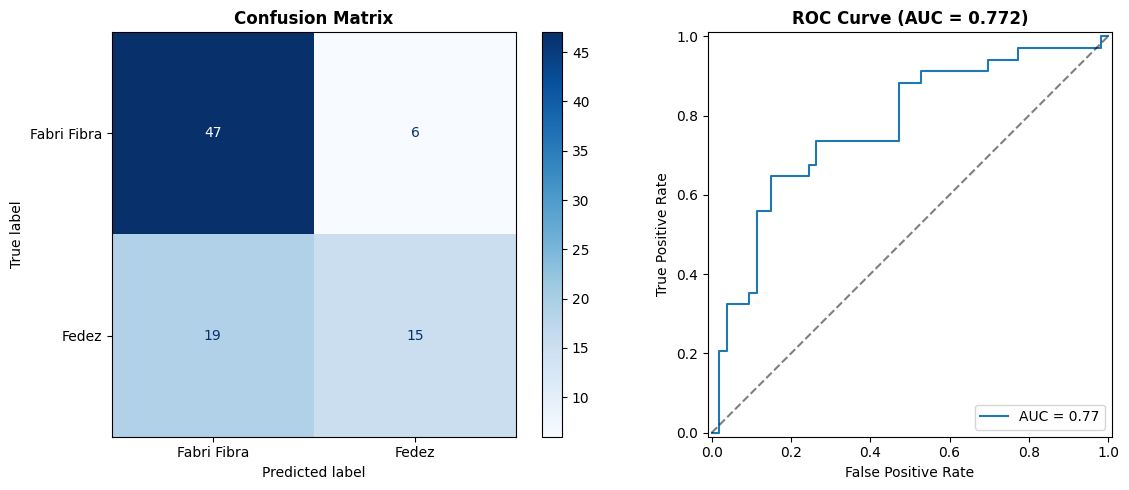

--- Shapelet Importance ---


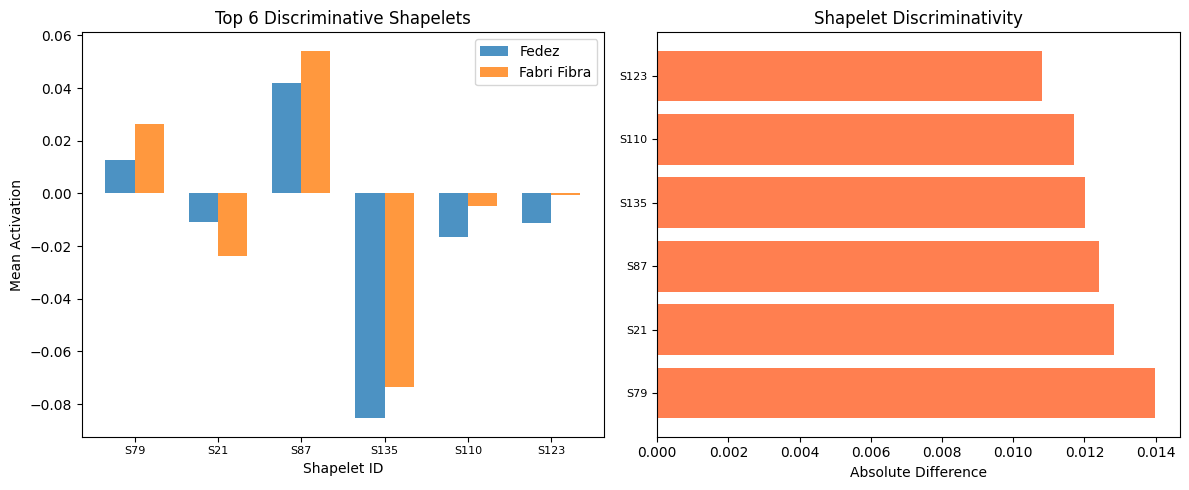


--- Shapelet Profiles ---


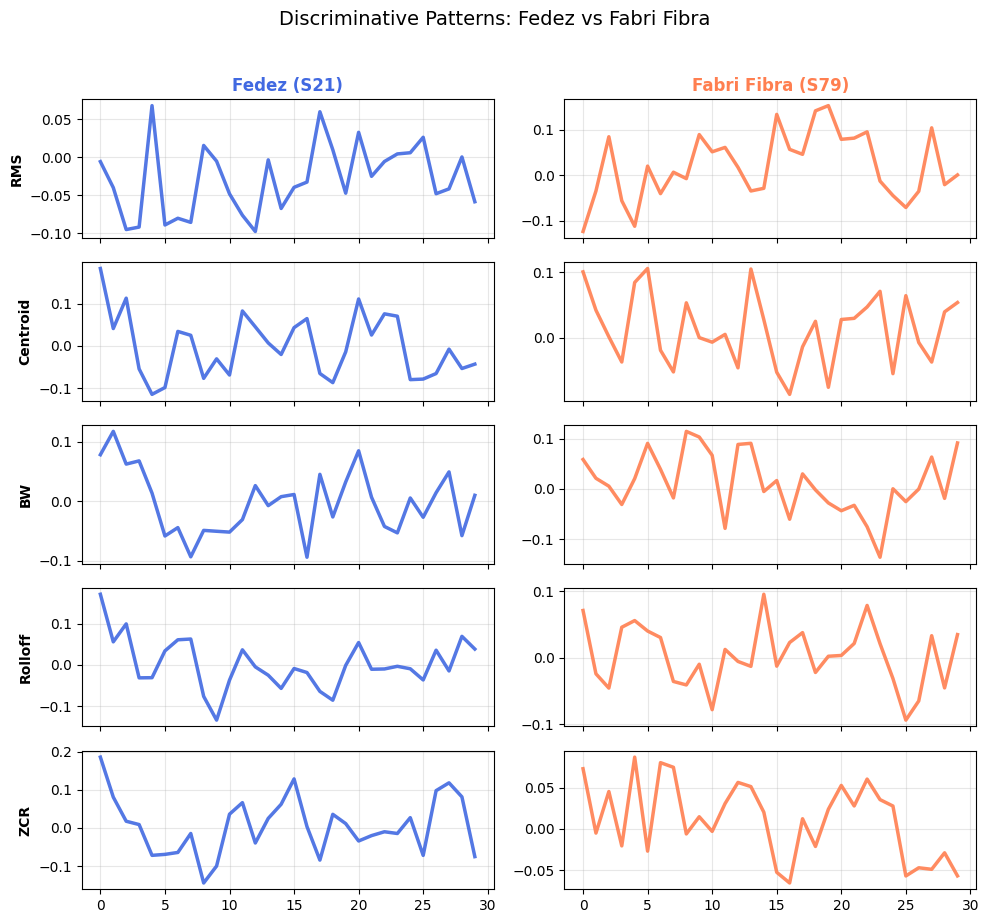

In [28]:
from shapelet_utils import *
best_preds = results['test_preds']

# 2. Evaluation
evaluate_shapelet_classifier(
    y_test, 
    best_preds,
    y_prob=probs[:, 1], 
    class_names=['Fabri Fibra', 'Fedez'] 
)

feats = ['RMS', 'Centroid', 'BW', 'Rolloff', 'ZCR']
classes = ['Fedez', 'Fabri Fibra']

imp = analyze_shapelet_importance(best_clf, X_test, y_test, input_format='NLC', class_names=classes)

print("--- Shapelet Importance ---")
plot_shapelet_importance(imp, top_k=6)

print("\n--- Shapelet Profiles ---")
plot_shapelet_profiles(best_clf, X_test, y_test, feats, classes)